In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.impute import SimpleImputer


sns.set_theme(style="whitegrid")

In [2]:
# Cargar el archivo Excel principal
df = pd.read_excel('reporte_final_diabetes.xlsx')

print(f"Dimensiones del dataset cargado: {df.shape[0]} filas y {df.shape[1]} columnas.")
display(df.head())

Dimensiones del dataset cargado: 60324 filas y 41 columnas.


,CODIGO_IAFAS_CRIPTO,CODIGO_IPRESS_CRIPTO,TIPO_DOC_PAGO,NUMERO_DOC_PAGO_CRIPTO,CORRELATIVO_ATENCION,TIPO_AFILIACION_DEL_PACIENTE,TIPO_DOC_IDENTIDAD,NUMERO_DOC_IDENTIDAD_CRIPTO,TIPO_COBERTURA,SUBTIPO_COBERTURA,...,TOTAL_GASTOS_CUBIERTOS,TOTAL_LIQUIDADO_IAFAS,FECHA_RECEPCION_INFO,UBIGEO_AFILIADO,PERIODO_PUBLICACION,MES_RECEPCION,AÑO_RECEPCION,MES_PRESTACION,AÑO_PRESTACION,EDAD_PACIENTE
0,0A9B686CF0271D607B6812D79A84E12B83356666,9144CC7E1B4608B4FC4FA31AA392DFAA5E0B5397,1,E11D02104D2C484617C8715D16F4FDD0788EC995,1,REGULAR,DNI,6B40353F62D25C6524DABA66622F0EA8F4BFF170,MEDICINAS ALTERNATIVAS,100,...,604.08,604.08,2025-12-04 21:30:26,140106.0,122025,DICIEMBRE,2025,9,2025,75
1,0A9B686CF0271D607B6812D79A84E12B83356666,842179BE8942CB524E09070812A4121ED27DDF1A,1,B81DE9144730B64AADEBB9B4A9B317E965E2ADAB,1,REGULAR,DNI,5A884E351351BA3C7EF736E494B83B8BF042B726,MEDICINAS ALTERNATIVAS,100,...,103.80,103.80,2025-12-04 21:35:23,240102.0,122025,DICIEMBRE,2025,10,2025,68
2,52C8E6961E279AA6459E8782F8F316B9220B782A,508E9DEDD8800D531EEA055C45B12CE9D3C0F444,1,5E2A0A8B490D2BDBADCFCE934939D1DFEE04DF39,1,REGULAR,DNI,CF65BE771B95C9156137B14A2E3F0B05F2953EB2,MEDICINAS ALTERNATIVAS,70,...,873.90,568.04,2025-12-05 18:20:44,140110.0,122025,DICIEMBRE,2025,10,2025,41
3,52C8E6961E279AA6459E8782F8F316B9220B782A,ADECE6AAAFE7E05BF751A5A446C440980D9B1AC2,1,2D4F3A0D3F177792A449542A198E1CA9F68B3C1F,1,REGULAR,DNI,779FBB15AE45C9F02E5138C89D90F3FDA157A1EE,MEDICINAS ALTERNATIVAS,100,...,1245.36,1058.56,2025-12-05 17:46:37,140140.0,122025,DICIEMBRE,2025,10,2025,57
4,52C8E6961E279AA6459E8782F8F316B9220B782A,40BA7B9DF53DC1EB6A4D06DE796576706A74BAD7,1,F07E76B4625CCC4A9BAA5D85A7F8737A304952B1,1,REGULAR,DNI,9D471FB0D796819957172238BB3F65B0D5A53608,MEDICINAS ALTERNATIVAS,100,...,1581.75,1315.36,2025-12-05 18:19:53,140140.0,122025,DICIEMBRE,2025,11,2025,52


=== RQ1: Cantidad de pacientes por mes y año ===


,AÑO_PRESTACION,MES_PRESTACION,TOTAL_PACIENTES
0,2022,8,2
1,2023,1,2
2,2023,2,3
3,2023,3,1
4,2023,4,5
5,2023,5,4
6,2023,6,2
7,2023,7,12
8,2023,8,21
9,2023,9,12


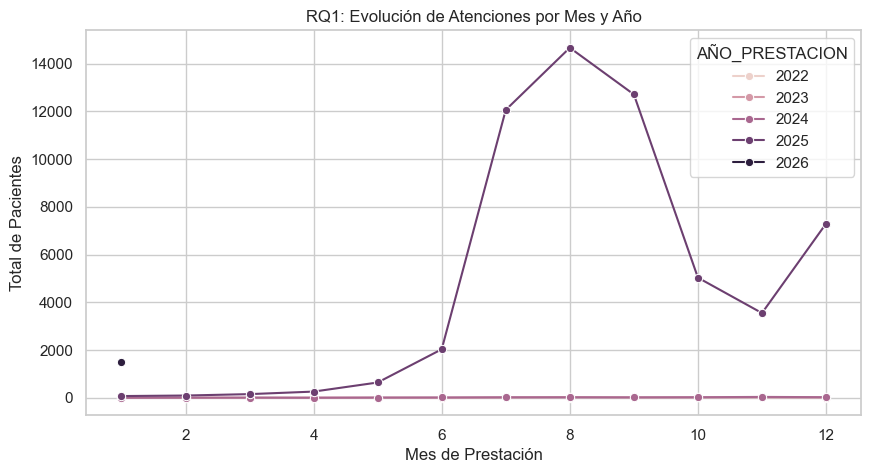

In [3]:
print("=== RQ1: Cantidad de pacientes por mes y año ===")
rq1_tabla = df.groupby(['AÑO_PRESTACION', 'MES_PRESTACION',]).size().reset_index(name='TOTAL_PACIENTES')
display(rq1_tabla.head(40))

plt.figure(figsize=(10, 5))
sns.lineplot(data=rq1_tabla, x='MES_PRESTACION', y='TOTAL_PACIENTES', hue='AÑO_PRESTACION', marker='o')
plt.title('RQ1: Evolución de Atenciones por Mes y Año')
plt.xlabel('Mes de Prestación')
plt.ylabel('Total de Pacientes')
plt.show()

=== RQ2: Distribución por Edad y Sexo ===


SEXO_PACIENTE,1,2
GRUPO_ETARIO,,
<18,277,284
18-35,1300,1085
36-50,8286,5142
51-65,15106,10340
>65,10092,8409


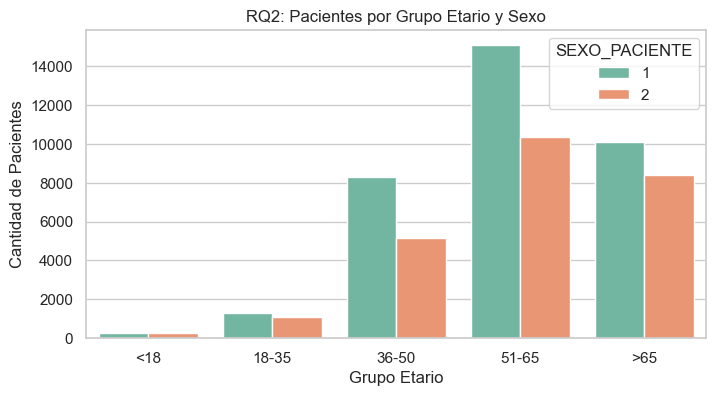

In [4]:
print("=== RQ2: Distribución por Edad y Sexo ===")
# Crear grupos etarios opcionales para mejor visualización
bins = [0, 18, 35, 50, 65, 100]
labels = ['<18', '18-35', '36-50', '51-65', '>65']
df['GRUPO_ETARIO'] = pd.cut(df['EDAD_PACIENTE'], bins=bins, labels=labels)

rq2_tabla = df.groupby(['GRUPO_ETARIO', 'SEXO_PACIENTE'], observed=False).size().unstack(fill_value=0)
display(rq2_tabla)

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='GRUPO_ETARIO', hue='SEXO_PACIENTE', palette='Set2')
plt.title('RQ2: Pacientes por Grupo Etario y Sexo')
plt.xlabel('Grupo Etario')
plt.ylabel('Cantidad de Pacientes')
plt.show()

=== RQ3: Casos por Región y Establecimiento (Top 10) ===


CODIGO_IAFAS_CRIPTO
D68FD8035E26A00787470F838D825A533FBE6A7F    24228
52C8E6961E279AA6459E8782F8F316B9220B782A    17297
6573F717AD2F71A161CC9D104526A196DDC0C641     6335
0A9B686CF0271D607B6812D79A84E12B83356666     2768
DA0578E76384568651D33510FBFAD28B0B8AF14E     2664
28448D6AE28A7F4C256D5B7C3469C47D8DD7C8ED     1996
EEEA06EF6C1B68CE97DC62F42BFCC74472960553     1509
E9C6B773F87A372066D8CFC2EF82F49FF823A083     1045
F961052ED1A96844121655AF5EC3B2DCD21D0FA1      954
E78D258514004C54F19A3167BCB99DCEB1A19C73      387
Name: count, dtype: int64

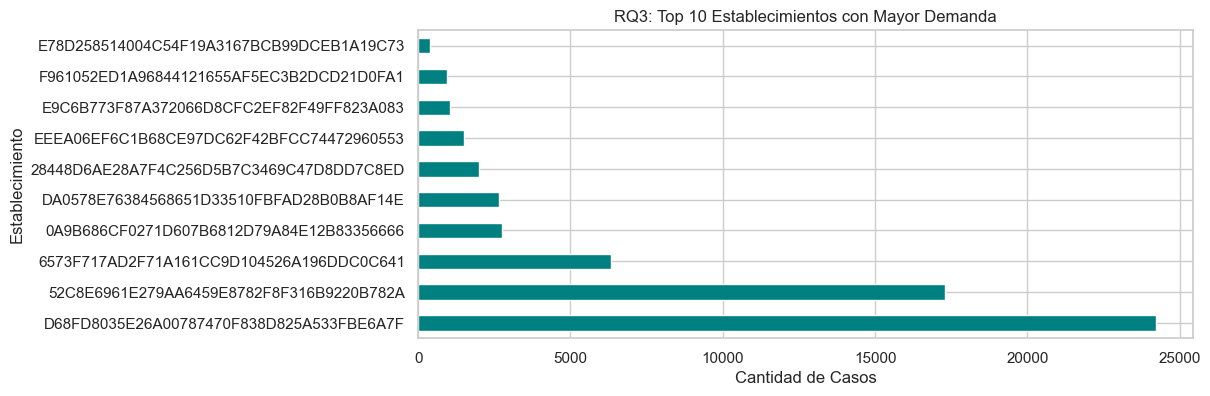

In [5]:
print("=== RQ3: Casos por Región y Establecimiento (Top 10) ===")
# Verificamos si existen las columnas de región/IPRESS, de lo contrario ajusta con tu dataset
col_establecimiento = 'ESTABLECIMIENTO_SALUD' if 'ESTABLECIMIENTO_SALUD' in df.columns else df.columns[0]
rq3_tabla = df[col_establecimiento].value_counts().head(10)
display(rq3_tabla)

plt.figure(figsize=(10, 4))
rq3_tabla.plot(kind='barh', color='teal')
plt.title('RQ3: Top 10 Establecimientos con Mayor Demanda')
plt.xlabel('Cantidad de Casos')
plt.ylabel('Establecimiento')
plt.show()

=== RQ4: Distribución según Tipo de Diabetes ===


,Cantidad,Porcentaje (%)
TIPO_DIABETES,,
TIPO 2,58737,97.37
TIPO 1,1587,2.63


C:\Users\Usuario\AppData\Local\Temp\ipykernel_23612\992744067.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='TIPO_DIABETES', palette='Pastel1')


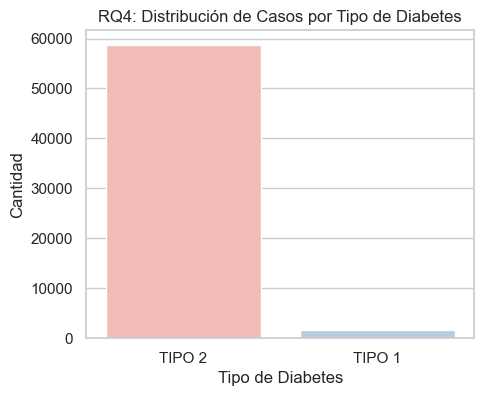

In [6]:
print("=== RQ4: Distribución según Tipo de Diabetes ===")
rq4_tabla = df['TIPO_DIABETES'].value_counts(dropna=False)
rq4_porcentaje = df['TIPO_DIABETES'].value_counts(normalize=True) * 100
rq4_resumen = pd.DataFrame({'Cantidad': rq4_tabla, 'Porcentaje (%)': rq4_porcentaje.round(2)})
display(rq4_resumen)

plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='TIPO_DIABETES', palette='Pastel1')
plt.title('RQ4: Distribución de Casos por Tipo de Diabetes')
plt.xlabel('Tipo de Diabetes')
plt.ylabel('Cantidad')
plt.show()

=== RQ5: Flujo de casos por mes (2025 - 2026) ===


,AÑO_PRESTACION,MES_PRESTACION,PERIODO,CASOS_TOTALES
0,2025,1,2025-01,72
1,2025,2,2025-02,94
2,2025,3,2025-03,153
3,2025,4,2025-04,259
4,2025,5,2025-05,640
5,2025,6,2025-06,2032
6,2025,7,2025-07,12062
7,2025,8,2025-08,14665
8,2025,9,2025-09,12709
9,2025,10,2025-10,5032


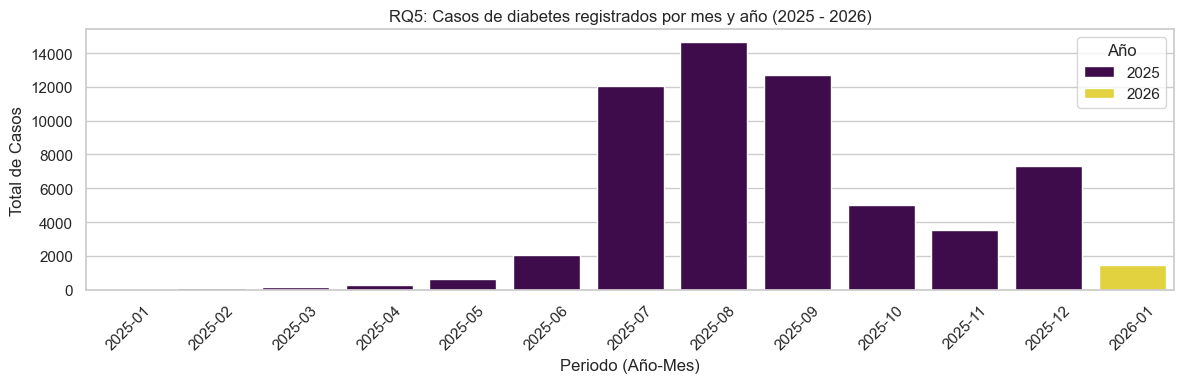

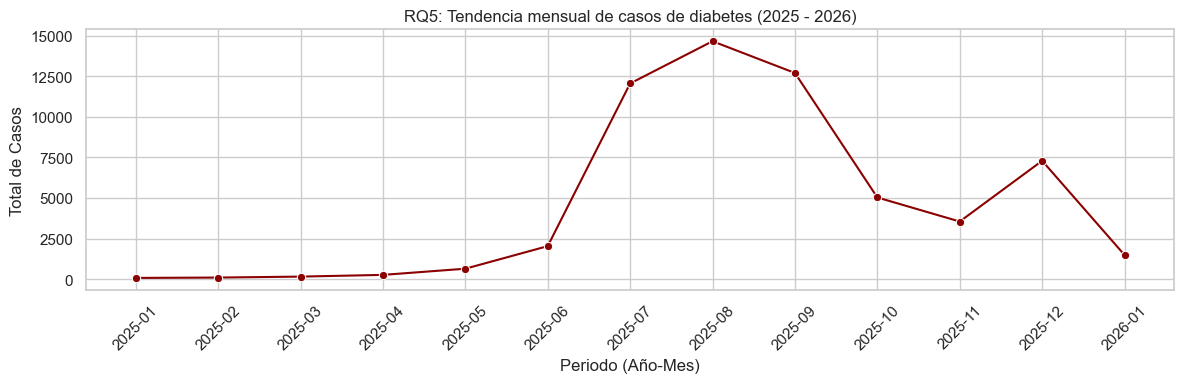

In [7]:
print("=== RQ5: Flujo de casos por mes (2025 - 2026) ===")

# Filtrar solo el periodo de interés del requerimiento
df_rq5 = df[df['AÑO_PRESTACION'].isin([2025, 2026])].copy()

# Crear un periodo AAAA-MM para poder ordenar correctamente el eje temporal
df_rq5['PERIODO'] = (
    df_rq5['AÑO_PRESTACION'].astype(str) + '-' +
    df_rq5['MES_PRESTACION'].astype(str).str.zfill(2)
)

# Agrupar por año y mes
rq5_tabla = (
    df_rq5.groupby(['AÑO_PRESTACION', 'MES_PRESTACION', 'PERIODO'])
    .size()
    .reset_index(name='CASOS_TOTALES')
    .sort_values('PERIODO')
)
display(rq5_tabla)

# Gráfico de barras: casos por mes, coloreado por año
plt.figure(figsize=(12, 4))
sns.barplot(data=rq5_tabla, x='PERIODO', y='CASOS_TOTALES',
            hue='AÑO_PRESTACION', dodge=False, palette='viridis')
plt.title('RQ5: Casos de diabetes registrados por mes y año (2025 - 2026)')
plt.xlabel('Periodo (Año-Mes)')
plt.ylabel('Total de Casos')
plt.xticks(rotation=45)
plt.legend(title='Año')
plt.tight_layout()
plt.show()

# Gráfico de línea: tendencia mensual (más claro para ver la evolución)
plt.figure(figsize=(12, 4))
sns.lineplot(data=rq5_tabla, x='PERIODO', y='CASOS_TOTALES',
             marker='o', color='darkred')
plt.title('RQ5: Tendencia mensual de casos de diabetes (2025 - 2026)')
plt.xlabel('Periodo (Año-Mes)')
plt.ylabel('Total de Casos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

=== RQ6: Perfil de pacientes con diabetes tipo 1 y tipo 2 ===


,TIPO_DIABETES,GRUPO_ETARIO,SEXO_LABEL,Total_Pacientes,Gasto_Promedio
0,TIPO 1,0-17 años,Femenino,111,521.043243
1,TIPO 1,0-17 años,Masculino,71,398.177606
2,TIPO 1,18-29 años,Femenino,82,534.142073
3,TIPO 1,18-29 años,Masculino,96,620.481354
4,TIPO 1,30-44 años,Femenino,128,529.085000
5,TIPO 1,30-44 años,Masculino,133,531.843383
6,TIPO 1,45-59 años,Femenino,186,603.257581
7,TIPO 1,45-59 años,Masculino,175,535.823429
8,TIPO 1,60 años a más,Femenino,305,741.059902
9,TIPO 1,60 años a más,Masculino,300,879.231200


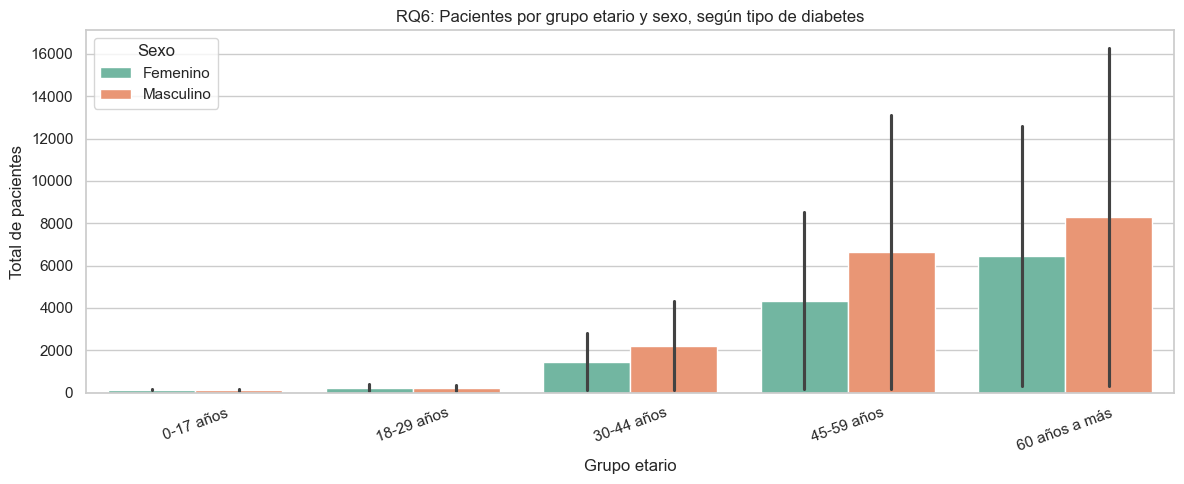

,TIPO_DIABETES,TIPO_AFILIACION_DEL_PACIENTE,TIPO_COBERTURA,Total_Pacientes,Gasto_Promedio,Gasto_Total
26,TIPO 2,SCTR,AMBULATORIO,2,7011.925000,14023.85
20,TIPO 2,REGULAR,AMBULATORIO,139,6973.664892,969339.42
12,TIPO 2,OTROS CONTRIBUTIVOS Y COMPLEMENTARIO,AMBULATORIO,15,5346.033333,80190.50
3,TIPO 1,POTESTATIVO (INDEPENDIENTE),AMBULATORIO,5,4665.814000,23329.07
7,TIPO 1,REGULAR,AMBULATORIO,57,4390.151754,250238.65
16,TIPO 2,POTESTATIVO (INDEPENDIENTE),AMBULATORIO,11,2192.145455,24113.60
6,TIPO 1,POTESTATIVO (INDEPENDIENTE),"NO APLICA (SEPELIO, PRESTACIONES ECONÓMICAS, E...",1,1299.530000,1299.53
27,TIPO 2,SCTR,HOSPITALARIO,1,922.510000,922.51
19,TIPO 2,POTESTATIVO (INDEPENDIENTE),"NO APLICA (SEPELIO, PRESTACIONES ECONÓMICAS, E...",15,877.590667,13163.86
28,TIPO 2,SCTR,MEDICINAS ALTERNATIVAS,11,638.039091,7018.43


,Tipo Diabetes,Grupo Etario,Sexo,Tipo Afiliación,Tipo Cobertura,Total Registros,Gasto Promedio,Gasto Total
145,TIPO 2,60 años a más,Masculino,OTROS CONTRIBUTIVOS Y COMPLEMENTARIO,AMBULATORIO,3,19886.370000,59659.11
152,TIPO 2,60 años a más,Masculino,REGULAR,AMBULATORIO,42,13587.580000,570678.36
138,TIPO 2,60 años a más,Femenino,REGULAR,AMBULATORIO,18,11833.506111,213003.11
61,TIPO 1,60 años a más,Masculino,REGULAR,AMBULATORIO,13,8132.826923,105726.75
117,TIPO 2,45-59 años,Femenino,SCTR,AMBULATORIO,2,7011.925000,14023.85
48,TIPO 1,60 años a más,Femenino,POTESTATIVO (INDEPENDIENTE),AMBULATORIO,3,5852.986667,17558.96
57,TIPO 1,60 años a más,Masculino,POTESTATIVO (INDEPENDIENTE),AMBULATORIO,1,5699.140000,5699.14
51,TIPO 1,60 años a más,Femenino,REGULAR,AMBULATORIO,10,5529.905000,55299.05
42,TIPO 1,45-59 años,Masculino,REGULAR,AMBULATORIO,6,3641.013333,21846.08
97,TIPO 2,30-44 años,Masculino,OTROS CONTRIBUTIVOS Y COMPLEMENTARIO,AMBULATORIO,2,3507.975000,7015.95


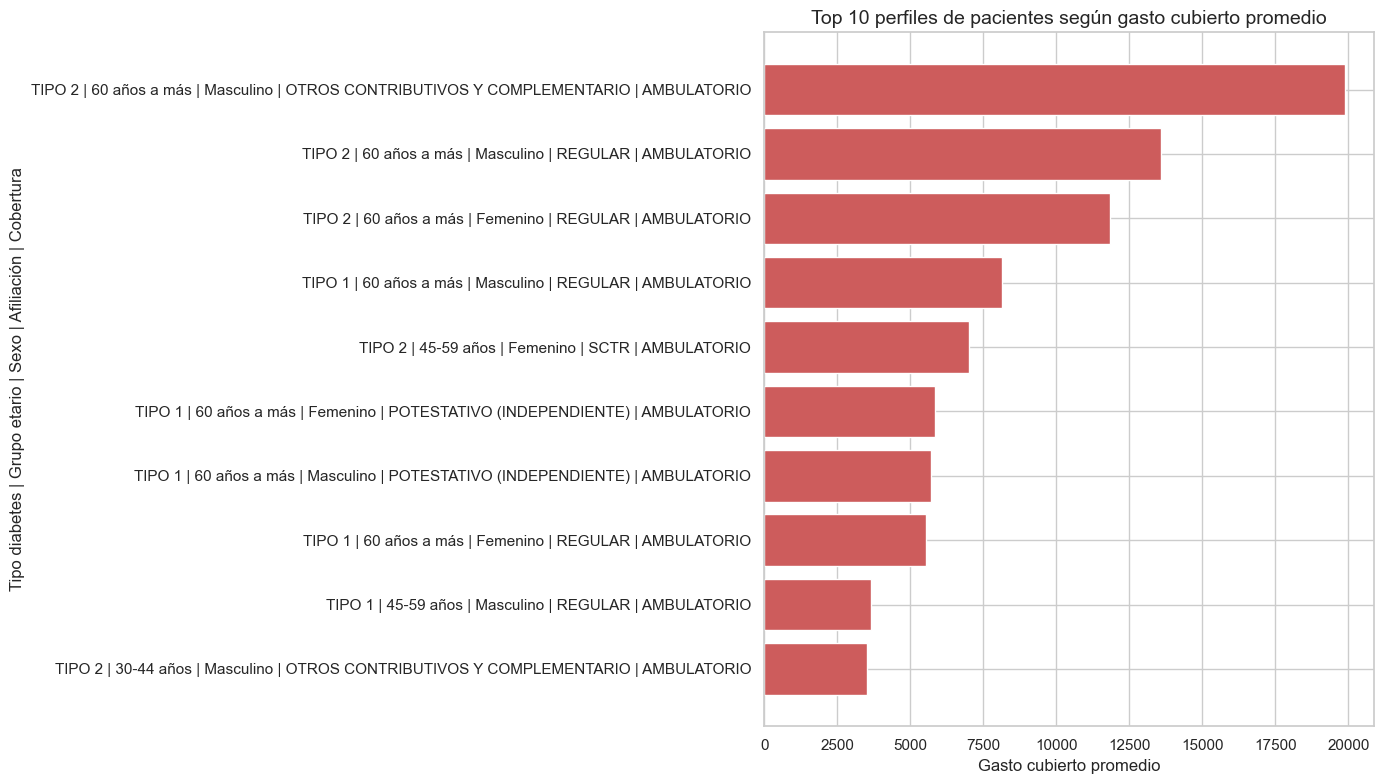

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=== RQ6: Perfil de pacientes con diabetes tipo 1 y tipo 2 ===")

# 1. Crear grupos de edad
intervalos = [0, 17, 29, 44, 59, 120]
nombres_grupos = ['0-17 años', '18-29 años', '30-44 años', '45-59 años', '60 años a más']

df['GRUPO_ETARIO'] = pd.cut(
    df['EDAD_PACIENTE'], bins=intervalos, labels=nombres_grupos, include_lowest=True
)

# 2. Etiquetar sexo para que se lea en los gráficos (ajusta el mapeo si 1/2 no corresponde a esto)
df['SEXO_LABEL'] = df['SEXO_PACIENTE'].map({1: 'Masculino', 2: 'Femenino'}).fillna('No especificado')

# =========================================================
# VISTA 1 - Comparativa Tipo 1 vs Tipo 2 por EDAD y SEXO
# =========================================================
rq6_edad_sexo = (
    df.groupby(['TIPO_DIABETES', 'GRUPO_ETARIO', 'SEXO_LABEL'], observed=True)['TOTAL_GASTOS_CUBIERTOS']
    .agg(Total_Pacientes='count', Gasto_Promedio='mean')
    .reset_index()
)
display(rq6_edad_sexo.sort_values(['TIPO_DIABETES', 'GRUPO_ETARIO']))

plt.figure(figsize=(12, 5))
sns.barplot(
    data=rq6_edad_sexo, x='GRUPO_ETARIO', y='Total_Pacientes',
    hue='SEXO_LABEL', palette='Set2'
)
plt.title('RQ6: Pacientes por grupo etario y sexo, según tipo de diabetes')
plt.xlabel('Grupo etario')
plt.ylabel('Total de pacientes')
plt.xticks(rotation=20)
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

# =========================================================
# VISTA 2 - Comparativa Tipo 1 vs Tipo 2 por AFILIACIÓN y COBERTURA
# =========================================================
rq6_afiliacion_cobertura = (
    df.groupby(['TIPO_DIABETES', 'TIPO_AFILIACION_DEL_PACIENTE', 'TIPO_COBERTURA'], observed=True)['TOTAL_GASTOS_CUBIERTOS']
    .agg(Total_Pacientes='count', Gasto_Promedio='mean', Gasto_Total='sum')
    .reset_index()
    .sort_values('Gasto_Promedio', ascending=False)
)
display(rq6_afiliacion_cobertura.head(10))

# =========================================================
# VISTA 3 - Top 10 perfiles completos según gasto cubierto promedio
#            (incluye tipo de diabetes, edad, sexo, afiliación y cobertura)
# =========================================================
rq6_resumen = (
    df.groupby(
        ['TIPO_DIABETES', 'GRUPO_ETARIO', 'SEXO_LABEL', 'TIPO_AFILIACION_DEL_PACIENTE', 'TIPO_COBERTURA'],
        observed=True
    )['TOTAL_GASTOS_CUBIERTOS']
    .agg(['count', 'mean', 'sum'])
    .reset_index()
)
rq6_resumen.columns = [
    'Tipo Diabetes', 'Grupo Etario', 'Sexo', 'Tipo Afiliación', 'Tipo Cobertura',
    'Total Registros', 'Gasto Promedio', 'Gasto Total'
]

rq6_grafico = rq6_resumen.sort_values('Gasto Promedio', ascending=False).head(10).copy()
display(rq6_grafico)

rq6_grafico['Perfil del Paciente'] = (
    rq6_grafico['Tipo Diabetes'].astype(str) + ' | ' +
    rq6_grafico['Grupo Etario'].astype(str) + ' | ' +
    rq6_grafico['Sexo'].astype(str) + ' | ' +
    rq6_grafico['Tipo Afiliación'].astype(str) + ' | ' +
    rq6_grafico['Tipo Cobertura'].astype(str)
)
rq6_grafico = rq6_grafico.sort_values('Gasto Promedio')

plt.figure(figsize=(14, 8))
plt.barh(rq6_grafico['Perfil del Paciente'], rq6_grafico['Gasto Promedio'], color='indianred')
plt.title('Top 10 perfiles de pacientes según gasto cubierto promedio', fontsize=14)
plt.xlabel('Gasto cubierto promedio')
plt.ylabel('Tipo diabetes | Grupo etario | Sexo | Afiliación | Cobertura')
plt.tight_layout()
plt.show()

In [9]:
print("=== RQ7: Predicción del Requerimiento de Laboratorio (Random Forest) ===")

# 2. Creación de la variable objetivo operativa (Y)
# 1 si requirió examen de laboratorio (gasto > 0), 0 en caso contrario
df['REQUIERE_LABORATORIO'] = (df['GASTO_EXAMENES_LABORATORIO'] > 0).astype(int)

# 3. Definición de variables predictoras (X) y objetivo (y)
predictors = [
    'EDAD_PACIENTE', 'SEXO_PACIENTE', 'TIPO_DIABETES', 
    'TIPO_AFILIACION_DEL_PACIENTE', 'TIPO_COBERTURA', 'TIPO_PROFESIONAL'
]

X = df[predictors].copy()
y = df['REQUIERE_LABORATORIO']

# 4. Partición del dataset (80% entrenamiento, 20% prueba estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
# Rellenar nulos DESPUÉS del split, usando valores de train
for col in predictors:
    if X[col].dtype == 'object':
        X_train[col] = X_train[col].fillna('DESCONOCIDO')
        X_test[col] = X_test[col].fillna('DESCONOCIDO')

# 5. Preprocesamiento (Estandarización y One-Hot Encoding)

num_cols = ['EDAD_PACIENTE']
cat_cols = ['SEXO_PACIENTE', 'TIPO_DIABETES', 'TIPO_AFILIACION_DEL_PACIENTE', 
            'TIPO_COBERTURA', 'TIPO_PROFESIONAL']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='DESCONOCIDO')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols)
    ])

# 6. Pipeline con el modelo Random Forest
rf_pipeline = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),       # balancea clases
    ('classifier', RandomForestClassifier(random_state=42, n_estimators=200,
        class_weight='balanced'))            # peso extra a clase minoritaria
])

# Entrenamiento
rf_pipeline.fit(X_train, y_train)

# 7. Predicción y Evaluación
y_pred_rf = rf_pipeline.predict(X_test)

print("=== REPORTE DE CLASIFICACIÓN (RQ7) ===")
print(classification_report(y_test, y_pred_rf))
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred_rf) * 100:.2f}%")

=== RQ7: Predicción del Requerimiento de Laboratorio (Random Forest) ===


=== REPORTE DE CLASIFICACIÓN (RQ7) ===
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      9308
           1       0.57      0.36      0.44      2757

    accuracy                           0.79     12065
   macro avg       0.70      0.64      0.66     12065
weighted avg       0.77      0.79      0.77     12065

Exactitud Global (Accuracy): 79.16%


Matriz de Confusión (Estructura: [[TN, FP], [FN, TP]]):
[[8563  745]
 [1769  988]]

Cantidad de Falsos Positivos (FP): 745


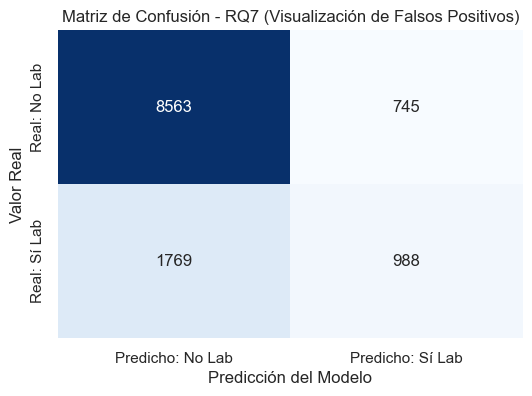

In [10]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calcular la matriz de confusión (aquí se encuentran los falsos positivos)
cm = confusion_matrix(y_test, y_pred_rf)

print("Matriz de Confusión (Estructura: [[TN, FP], [FN, TP]]):")
print(cm)

# Extraer explícitamente los Falsos Positivos (FP)
# En una matriz 2x2, el Falso Positivo está en la fila 0, columna 1
false_positives = cm[0, 1]
print(f"\nCantidad de Falsos Positivos (FP): {false_positives}")

# 2. Visualización gráfica de la Matriz de Confusión (para ver los Falsos Positivos visualmente)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicho: No Lab', 'Predicho: Sí Lab'],
            yticklabels=['Real: No Lab', 'Real: Sí Lab'])
plt.title('Matriz de Confusión - RQ7 (Visualización de Falsos Positivos)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

ROC-AUC: 0.655


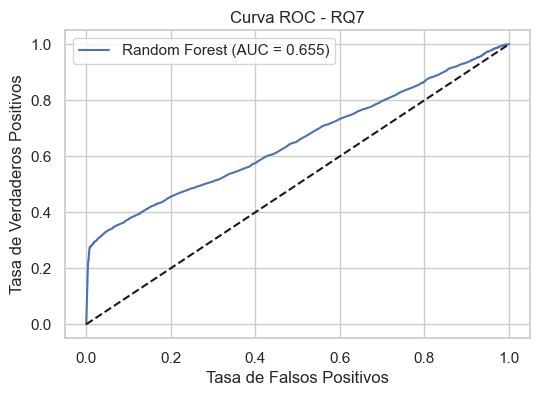

In [11]:
from sklearn.metrics import roc_auc_score, roc_curve

y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob_rf)
print(f"ROC-AUC: {roc_auc:.3f}")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - RQ7')
plt.legend()
plt.show()

In [12]:
print("=== RQ8: Evaluación Comparativa de Algoritmos ===")

models = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42,
        class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42,
        class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

comparacion_resultados = []

for name, model in models.items():
    
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    if name == 'Gradient Boosting':
        pipe.fit(X_train, y_train,
                 classifier__sample_weight=np.where(y_train == 1, 3.5, 1.0))
    else:
        pipe.fit(X_train, y_train)

    
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    roc_auc_modelo = roc_auc_score(y_test, y_prob)
    
    comparacion_resultados.append({
        'Modelo': name,
        'Exactitud (%)': round(acc * 100, 2),
        'F1-Score (Macro)': round(f1_macro, 3),
        'ROC-AUC': round(roc_auc_modelo, 3)
    })

df_comparacion = pd.DataFrame(comparacion_resultados)
display(df_comparacion)

=== RQ8: Evaluación Comparativa de Algoritmos ===


,Modelo,Exactitud (%),F1-Score (Macro),ROC-AUC
0,Regresión Logística,80.97,0.669,0.672
1,Random Forest,78.35,0.654,0.662
2,Gradient Boosting,79.98,0.667,0.678


In [13]:
!pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


=== RQ8: Patrones de posibles complicaciones asociados a la diabetes ===

Proporcion de atenciones con alguna complicacion registrada:


CON_COMPLICACION
0    89.8
1    10.2
Name: proportion, dtype: float64

,Complicacion,Cantidad,Porcentaje (%)
0,Sin complicaciones,54162,89.79
1,Complicaciones multiples,1701,2.82
2,Complicaciones no especificadas,1597,2.65
3,Complicaciones renales,1065,1.77
4,Complicaciones neurologicas,597,0.99
5,Con coma,455,0.75
6,Otras complicaciones especificadas,451,0.75
7,Complicaciones circulatorias perifericas,188,0.31
8,Con cetoacidosis,70,0.12
9,Complicaciones oculares (oftalmicas),38,0.06


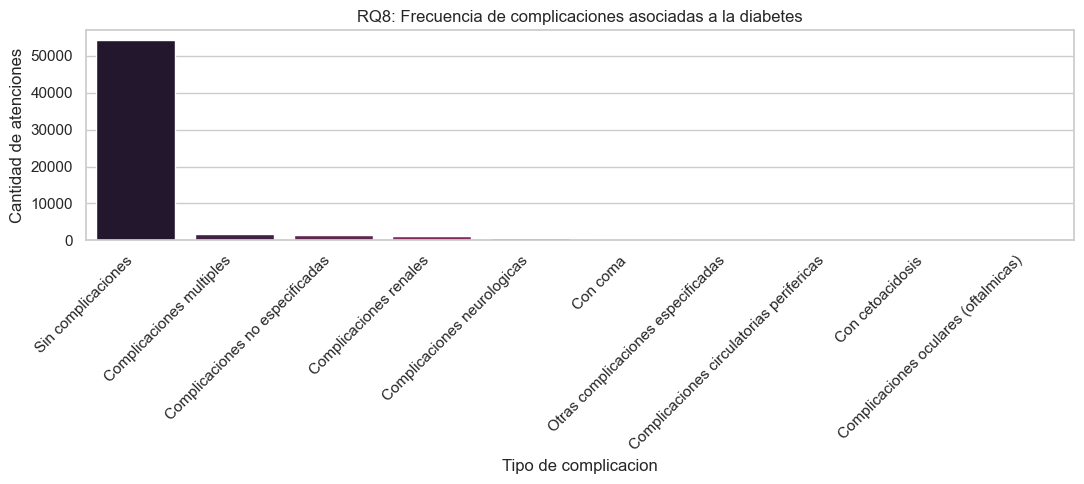

Distribucion de complicaciones segun tipo de diabetes (%):


TIPO_DIABETES,TIPO 1,TIPO 2
COMPLICACION_DIABETES,,
Sin complicaciones,63.71,90.49
Complicaciones multiples,7.50,2.69
Complicaciones no especificadas,5.10,2.58
Complicaciones renales,6.99,1.62
Complicaciones neurologicas,6.18,0.85
Con coma,1.45,0.74
Otras complicaciones especificadas,5.29,0.62
Complicaciones circulatorias perifericas,1.70,0.27
Con cetoacidosis,1.58,0.08


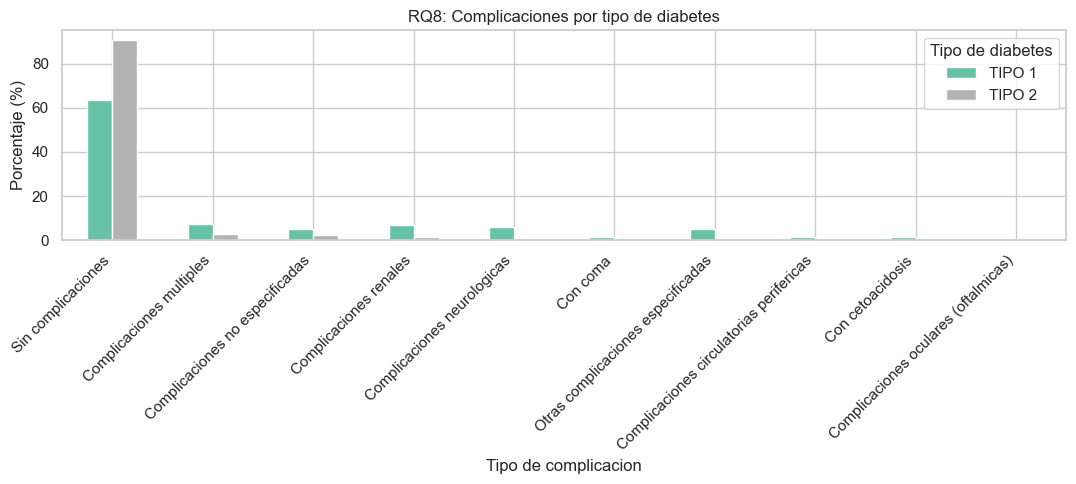

,GRUPO_ETARIO,SEXO_LABEL,Tasa_Complicaciones_%
0,0-17 años,Femenino,11.877395
1,0-17 años,Masculino,4.347826
2,18-29 años,Femenino,10.229645
3,18-29 años,Masculino,6.903766
4,30-44 años,Femenino,6.848382
5,30-44 años,Masculino,8.262044
6,45-59 años,Femenino,8.442604
7,45-59 años,Masculino,8.656088
8,60 años a más,Femenino,11.595439
9,60 años a más,Masculino,12.596432


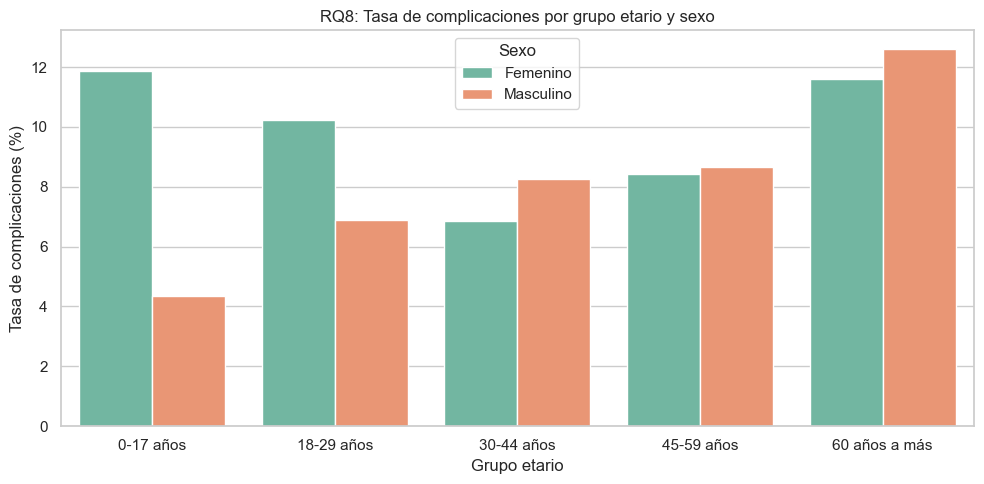

Modelo logit convergido: True
Registros usados en el modelo: 60285


,Odds Ratio,IC 2.5%,IC 97.5%,p-valor
TIPO_COBERTURA_MEDICINAS ALTERNATIVAS,0.136,0.102,0.180,0.000
TIPO_DIABETES_TIPO 2,0.169,0.151,0.190,0.000
"TIPO_COBERTURA_NO APLICA (SEPELIO, PRESTACIONES ECONÓMICAS, ETC.)",0.304,0.215,0.430,0.000
TIPO_AFILIACION_DEL_PACIENTE_POTESTATIVO (INDEPENDIENTE),0.440,0.386,0.502,0.000
TIPO_AFILIACION_DEL_PACIENTE_REGULAR,0.468,0.422,0.519,0.000
TIPO_COBERTURA_HOSPITALARIO,0.806,0.532,1.220,0.307
SEXO_PACIENTE_2,0.888,0.840,0.938,0.000
EDAD_PACIENTE,1.022,1.020,1.024,0.000


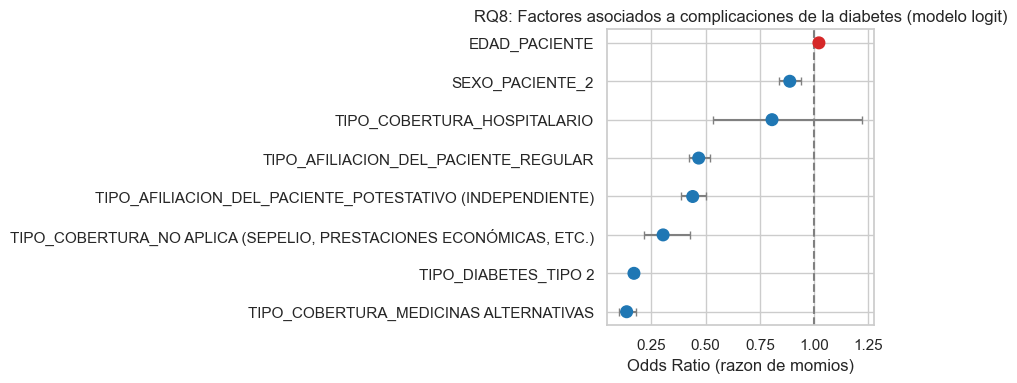

In [14]:
import statsmodels.api as sm

print("=== RQ8: Patrones de posibles complicaciones asociados a la diabetes ===\n")

# 1. Extraer el tipo de complicacion del diagnostico CIE-10
#    (columna PRIMER_DIAGNOSTICO con codigos E10.x / E11.x). El ultimo
#    digito del codigo identifica la complicacion asociada a la diabetes.
df['SUFIJO_DIAGNOSTICO'] = df['PRIMER_DIAGNOSTICO'].str.extract(r'\.(\d)$')

mapa_complicaciones = {
    '9': 'Sin complicaciones',
    '0': 'Con coma',
    '1': 'Con cetoacidosis',
    '2': 'Complicaciones renales',
    '3': 'Complicaciones oculares (oftalmicas)',
    '4': 'Complicaciones neurologicas',
    '5': 'Complicaciones circulatorias perifericas',
    '6': 'Otras complicaciones especificadas',
    '7': 'Complicaciones multiples',
    '8': 'Complicaciones no especificadas'
}

df['COMPLICACION_DIABETES'] = (
    df['SUFIJO_DIAGNOSTICO'].map(mapa_complicaciones).fillna('Sin complicaciones')
)
df['CON_COMPLICACION'] = (df['SUFIJO_DIAGNOSTICO'] != '9').astype(int)

print("Proporcion de atenciones con alguna complicacion registrada:")
display(df['CON_COMPLICACION'].value_counts(normalize=True).mul(100).round(1))

rq8_complicaciones = (
    df['COMPLICACION_DIABETES']
    .value_counts()
    .reset_index()
)
rq8_complicaciones.columns = ['Complicacion', 'Cantidad']
rq8_complicaciones['Porcentaje (%)'] = (
    rq8_complicaciones['Cantidad'] / len(df) * 100
).round(2)
display(rq8_complicaciones)

plt.figure(figsize=(11, 5))
sns.barplot(
    data=rq8_complicaciones, x='Complicacion', y='Cantidad',
    palette='rocket', order=rq8_complicaciones['Complicacion'],
    hue=rq8_complicaciones['Complicacion'], legend=False
)
plt.title('RQ8: Frecuencia de complicaciones asociadas a la diabetes')
plt.xlabel('Tipo de complicacion')
plt.ylabel('Cantidad de atenciones')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Patron por tipo de diabetes (TIPO 1 vs TIPO 2)
rq8_por_tipo = (
    pd.crosstab(df['COMPLICACION_DIABETES'], df['TIPO_DIABETES'], normalize='columns') * 100
).round(2)
rq8_por_tipo = rq8_por_tipo.reindex(rq8_complicaciones['Complicacion'].tolist())
print("Distribucion de complicaciones segun tipo de diabetes (%):")
display(rq8_por_tipo)

fig, ax = plt.subplots(figsize=(11, 5))
rq8_por_tipo.plot(kind='bar', ax=ax, colormap='Set2')
plt.title('RQ8: Complicaciones por tipo de diabetes')
plt.xlabel('Tipo de complicacion')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo de diabetes')
plt.tight_layout()
plt.show()

# 3. Tasa de complicaciones por grupo etario y sexo
bins = [0, 17, 29, 44, 59, 120]
labels_g = ['0-17 años', '18-29 años', '30-44 años', '45-59 años', '60 años a más']
df['GRUPO_ETARIO'] = pd.cut(df['EDAD_PACIENTE'], bins=bins, labels=labels_g, include_lowest=True)
df['SEXO_LABEL'] = df['SEXO_PACIENTE'].map({1: 'Masculino', 2: 'Femenino'}).fillna('No especificado')

rq8_tasa_edad_sexo = (
    df.groupby(['GRUPO_ETARIO', 'SEXO_LABEL'], observed=True)['CON_COMPLICACION']
    .mean()
    .mul(100)
    .reset_index()
    .rename(columns={'CON_COMPLICACION': 'Tasa_Complicaciones_%'})
)
display(rq8_tasa_edad_sexo)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=rq8_tasa_edad_sexo, x='GRUPO_ETARIO', y='Tasa_Complicaciones_%',
    hue='SEXO_LABEL', palette='Set2'
)
plt.title('RQ8: Tasa de complicaciones por grupo etario y sexo')
plt.xlabel('Grupo etario')
plt.ylabel('Tasa de complicaciones (%)')
plt.legend(title='Sexo')
plt.tight_layout()
plt.show()

# 4. Modelo analitico: factores asociados a presentar una complicacion
predictors_rq8 = [
    'EDAD_PACIENTE', 'SEXO_PACIENTE', 'TIPO_DIABETES',
    'TIPO_AFILIACION_DEL_PACIENTE', 'TIPO_COBERTURA'
]
df_rq8 = df[predictors_rq8 + ['CON_COMPLICACION']].copy()
for col in predictors_rq8:
    if df_rq8[col].dtype == 'object':
        df_rq8[col] = df_rq8[col].fillna('DESCONOCIDO')

# 4.1. Descartar categorias muy pequenas para evitar separacion casi perfecta
#      (el modelo logit de statsmodels no converge si una categoria no tiene
#      casos positivos o negativos en la muestra)
for col in predictors_rq8:
    if df_rq8[col].dtype == 'object':
        vc = df_rq8[col].value_counts()
        categ_min = vc[vc < 100].index
        df_rq8 = df_rq8[~df_rq8[col].isin(categ_min)]

cat_cols_rq8 = ['SEXO_PACIENTE', 'TIPO_DIABETES', 'TIPO_AFILIACION_DEL_PACIENTE', 'TIPO_COBERTURA']
X_rq8 = pd.get_dummies(df_rq8[predictors_rq8], columns=cat_cols_rq8, drop_first=True)
X_rq8 = sm.add_constant(X_rq8.astype(float))
y_rq8 = df_rq8['CON_COMPLICACION']

modelo_rq8 = sm.Logit(y_rq8, X_rq8).fit(disp=False, maxiter=300)
print(f"Modelo logit convergido: {modelo_rq8.mle_retvals.get('converged')}")
print(f"Registros usados en el modelo: {len(df_rq8)}")

resumen_rq8 = pd.DataFrame({
    'Odds Ratio': np.exp(modelo_rq8.params),
    'IC 2.5%': np.exp(modelo_rq8.conf_int()[0]),
    'IC 97.5%': np.exp(modelo_rq8.conf_int()[1]),
    'p-valor': modelo_rq8.pvalues
}).drop('const').sort_values('Odds Ratio')

display(resumen_rq8.round(3))

# 4.2. Forest plot de odds ratios
y_pos = np.arange(len(resumen_rq8))
plt.figure(figsize=(9, max(4, len(resumen_rq8) * 0.4)))
colores = ['#d62728' if or_ > 1 else '#1f77b4' for or_ in resumen_rq8['Odds Ratio']]
plt.errorbar(
    resumen_rq8['Odds Ratio'], y_pos,
    xerr=[resumen_rq8['Odds Ratio'] - resumen_rq8['IC 2.5%'],
          resumen_rq8['IC 97.5%'] - resumen_rq8['Odds Ratio']],
    fmt='none', ecolor='gray', capsize=3, zorder=2
)
plt.scatter(resumen_rq8['Odds Ratio'], y_pos, color=colores, zorder=3, s=70)
plt.yticks(y_pos, resumen_rq8.index)
plt.axvline(x=1, linestyle='--', color='gray')
plt.xlabel('Odds Ratio (razon de momios)')
plt.title('RQ8: Factores asociados a complicaciones de la diabetes (modelo logit)')
plt.tight_layout()
plt.show()


    ## RQ8 - Interpretación: Patrón de posibles complicaciones asociadas a la diabetes

Usando el diagnóstico CIE-10 de la columna `PRIMER_DIAGNOSTICO` (códigos E10.x / E11.x) se identifica que:

- El **10.2 %** de las atenciones presenta alguna complicación asociada a la diabetes.
- Las complicaciones más frecuentes son las **múltiples (2.8 %)**, las **no especificadas (2.6 %)** y las **renales (1.8 %)**, seguidas de neurológicas, coma y otras especificadas.
- La **diabetes tipo 1** concentra una tasa de complicaciones mucho mayor (≈36 %) frente a la **tipo 2** (≈10 %), destacando complicaciones múltiples, renales, neurológicas y no especificadas.
- La tasa de complicaciones **aumenta con la edad** (máxima en 60 años a más) y es ligeramente mayor en mujeres en los grupos de mayor edad.
- El modelo logit convergido confirma los patrones: la **edad incrementa la odds** (OR ≈ 1.02 por año), mientras que la **diabetes tipo 2** (OR ≈ 0.17) y la cobertura mayoritaria de **medicinas alternativas** (OR ≈ 0.14) se asocian a una menor odds de complicación.

**Conclusión:** el patrón evidencia que las complicaciones se concentran en pacientes con diabetes tipo 1 y en adultos mayores, lo que permite priorizar el seguimiento clínico de estos perfiles y orientar la asignación de recursos de la clínica.
